### Factory Sensor Failure Prediction

本项目基于 Kaggle 工厂传感器模拟数据集，构建设备未来 7 天内是否发生故障的预测模型。项目流程包括数据读取、探索性数据分析、统计特征筛选、特征工程、模型训练、模型对比与阈值优化。

设备故障预测是预测性维护中的典型问题。本项目将 `Failure_Within_7_Days` 作为分类目标，预测设备是否会在未来7天内发生故障。

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

#### 1. Data Loading and Overview

In [32]:
df = pd.read_csv("factory_sensor_simulator_2040.csv")
df.head()

,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,153,4,5,True,3,162.0,False,NaN,NaN,NaN,NaN,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,136,5,2,True,4,147.0,False,NaN,NaN,40.92,NaN,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,258,1,1,True,6,0.0,True,NaN,NaN,NaN,NaN,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,43,4,1,False,4,161.0,False,NaN,NaN,NaN,NaN,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,346,4,2,False,1,765.0,False,NaN,NaN,NaN,NaN,0


In [5]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (500000, 22)
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Machine_ID                  500000 non-null  str    
 1   Machine_Type                500000 non-null  str    
 2   Installation_Year           500000 non-null  int64  
 3   Operational_Hours           500000 non-null  int64  
 4   Temperature_C               500000 non-null  float64
 5   Vibration_mms               500000 non-null  float64
 6   Sound_dB                    500000 non-null  float64
 7   Oil_Level_pct               500000 non-null  float64
 8   Coolant_Level_pct           500000 non-null  float64
 9   Power_Consumption_kW        500000 non-null  float64
 10  Last_Maintenance_Days_Ago   500000 non-null  int64  
 11  Maintenance_History_Count   500000 non-null  int64  
 12  Failure_History_Count       500000 non-null  int64  
 1

In [6]:
df.describe()

,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
count,500000.000000,500000.000000,500000.000000,500000.00000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,15156.000000,30340.000000,45624.000000,45214.000000,500000.000000
mean,2019.962360,50012.424764,59.997682,9.99114,75.003477,69.456568,64.114159,149.922161,182.257866,5.003128,2.000588,3.000840,452.422338,74.995513,119.917514,39.984794,499.760966,0.602098
std,11.829812,28861.849078,14.986973,4.99953,9.990791,18.847444,23.152998,79.955937,105.552537,2.238043,1.413087,1.730541,288.971269,10.035133,15.017048,9.989653,50.012057,1.203647
min,2000.000000,0.000000,-15.730000,-17.82000,23.650000,0.000000,0.000000,-222.740000,0.000000,0.000000,0.000000,0.000000,0.000000,34.970000,52.680000,-0.160000,296.440000,0.000000
25%,2010.000000,25055.000000,49.890000,6.62000,68.270000,56.540000,48.130000,96.090000,91.000000,3.000000,1.000000,2.000000,200.000000,68.250000,109.820000,33.200000,465.940000,0.000000
50%,2020.000000,49973.000000,60.000000,10.00000,75.000000,70.030000,65.010000,149.950000,182.000000,5.000000,2.000000,3.000000,451.000000,74.950000,119.860000,40.030000,499.770000,0.000000
75%,2030.000000,74995.000000,70.050000,13.36000,81.730000,83.540000,81.840000,203.900000,274.000000,6.000000,3.000000,4.000000,700.000000,81.682500,130.072500,46.750000,533.307500,1.000000
max,2040.000000,100000.000000,127.330000,32.47000,120.700000,100.000000,100.000000,544.200000,365.000000,18.000000,12.000000,13.000000,1133.000000,114.320000,185.380000,80.790000,694.170000,11.000000


#### 2.Missing Value Analysis

部分机器专属字段存在大量缺失，例如激光强度、液压压力、冷却液流量等。由于这些字段缺失比例较高，后续建模中将其删除。

In [7]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Laser_Intensity           484844
Hydraulic_Pressure_bar    469660
Heat_Index                454786
Coolant_Flow_L_min        454376
dtype: int64

#### 3.Target Distribution

In [8]:
target_counts = df['Failure_Within_7_Days'].value_counts()
target_counts

Failure_Within_7_Days
False    469968
True      30032
Name: count, dtype: int64

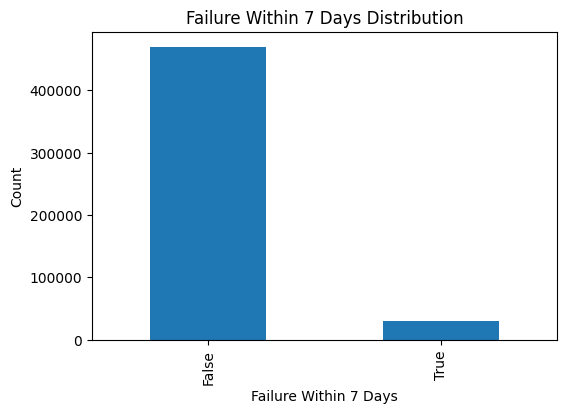

In [9]:
plt.figure(figsize=(6, 4))
target_counts.plot(kind='bar')
plt.title('Failure Within 7 Days Distribution')
plt.xlabel('Failure Within 7 Days')
plt.ylabel('Count')
plt.show()

#### 4.Numerical Feature Distribution

In [10]:
numerical_cols = [
    'Installation_Year',
    'Operational_Hours',
    'Temperature_C',
    'Vibration_mms',
    'Sound_dB',
    'Oil_Level_pct',
    'Coolant_Level_pct',
    'Power_Consumption_kW',
    'Last_Maintenance_Days_Ago',
    'Maintenance_History_Count',
    'Failure_History_Count',
    'Error_Codes_Last_30_Days',
    'AI_Override_Events'
]

df[numerical_cols].describe()

,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,Error_Codes_Last_30_Days,AI_Override_Events
count,500000.000000,500000.000000,500000.000000,500000.00000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,2019.962360,50012.424764,59.997682,9.99114,75.003477,69.456568,64.114159,149.922161,182.257866,5.003128,2.000588,3.000840,0.602098
std,11.829812,28861.849078,14.986973,4.99953,9.990791,18.847444,23.152998,79.955937,105.552537,2.238043,1.413087,1.730541,1.203647
min,2000.000000,0.000000,-15.730000,-17.82000,23.650000,0.000000,0.000000,-222.740000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2010.000000,25055.000000,49.890000,6.62000,68.270000,56.540000,48.130000,96.090000,91.000000,3.000000,1.000000,2.000000,0.000000
50%,2020.000000,49973.000000,60.000000,10.00000,75.000000,70.030000,65.010000,149.950000,182.000000,5.000000,2.000000,3.000000,0.000000
75%,2030.000000,74995.000000,70.050000,13.36000,81.730000,83.540000,81.840000,203.900000,274.000000,6.000000,3.000000,4.000000,1.000000
max,2040.000000,100000.000000,127.330000,32.47000,120.700000,100.000000,100.000000,544.200000,365.000000,18.000000,12.000000,13.000000,11.000000


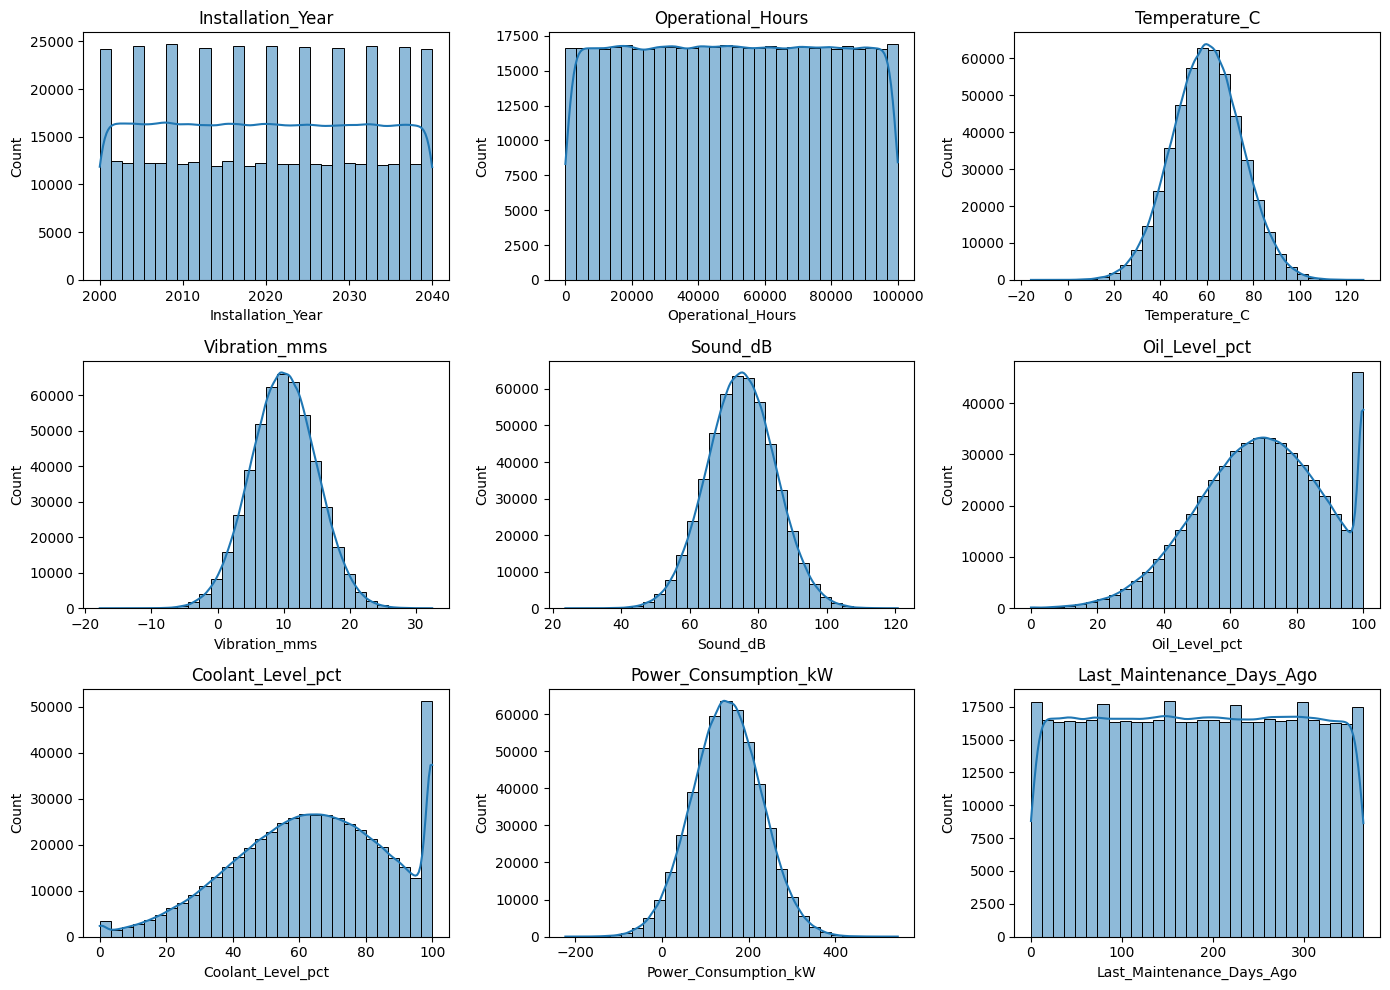

In [11]:
plt.figure(figsize=(14, 10))

for i, col in enumerate(numerical_cols[:9]):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

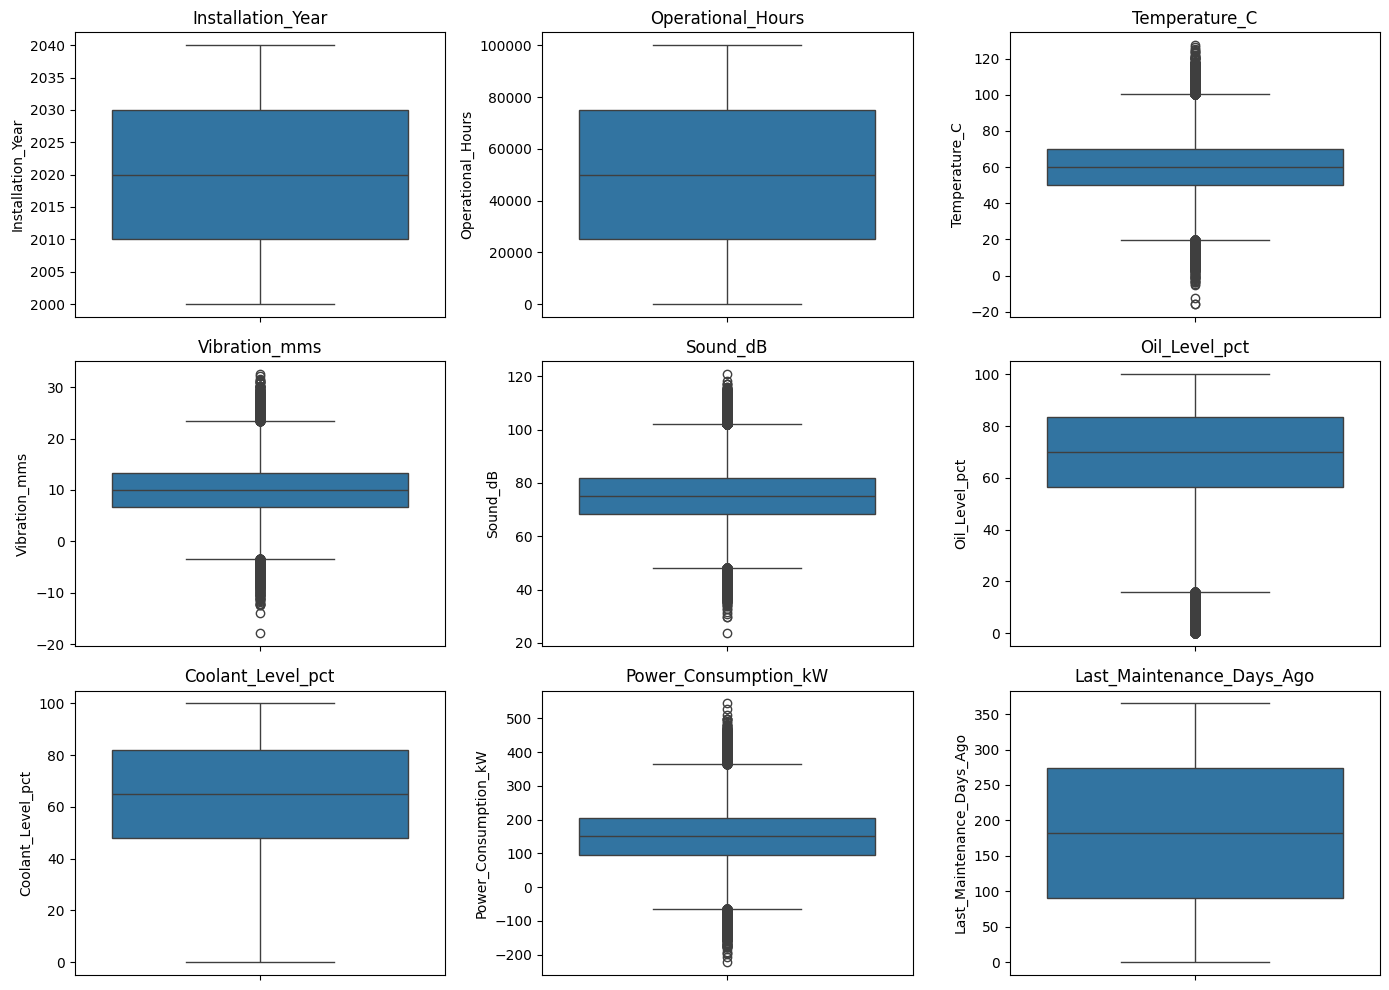

In [12]:
plt.figure(figsize=(14, 10))

for i, col in enumerate(numerical_cols[:9]):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### 5.Statistical Feature Screening
为判断哪些变量与设备故障更相关，本项目比较故障组与非故障组的均值差异，并计算相关系数、t 检验 p 值和 Cohen's d 效应量。

In [13]:
df['Failure_Label'] = df['Failure_Within_7_Days'].astype(int)

group_mean = df.groupby('Failure_Within_7_Days')[numerical_cols].mean()
group_mean

,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,Error_Codes_Last_30_Days,AI_Override_Events
Failure_Within_7_Days,,,,,,,,,,,,,
False,2019.967960,47117.306219,59.898466,9.944222,75.006897,69.460782,64.126754,149.920728,182.249879,5.003302,1.999862,3.001238,0.602720
True,2019.874734,95317.868041,61.550314,10.725357,74.949953,69.390622,63.917049,149.944583,182.382858,5.000400,2.011954,2.994606,0.592368


In [14]:
corr_with_target = df[numerical_cols + ['Failure_Label']].corr()['Failure_Label'].sort_values(ascending=False)
corr_with_target

Failure_Label                1.000000
Operational_Hours            0.396812
Vibration_mms                0.037124
Temperature_C                0.026189
Failure_History_Count        0.002033
Last_Maintenance_Days_Ago    0.000299
Power_Consumption_kW         0.000071
Maintenance_History_Count   -0.000308
Oil_Level_pct               -0.000885
Error_Codes_Last_30_Days    -0.000911
Sound_dB                    -0.001354
Installation_Year           -0.001872
AI_Override_Events          -0.002043
Coolant_Level_pct           -0.002152
Name: Failure_Label, dtype: float64

In [15]:
from scipy.stats import ttest_ind

results = []

for col in numerical_cols:
    normal = df[df['Failure_Within_7_Days'] == False][col].dropna()
    failure = df[df['Failure_Within_7_Days'] == True][col].dropna()
    
    normal_mean = normal.mean()
    failure_mean = failure.mean()
    mean_diff = failure_mean - normal_mean
    diff_pct = mean_diff / normal_mean * 100 if normal_mean != 0 else np.nan
    
    corr = df[[col, 'Failure_Label']].corr().iloc[0, 1]
    
    t_stat, p_value = ttest_ind(normal, failure, equal_var=False)
    
    pooled_std = np.sqrt((normal.std() ** 2 + failure.std() ** 2) / 2)
    cohen_d = mean_diff / pooled_std if pooled_std != 0 else np.nan
    
    results.append({
        'Feature': col,
        'Normal_Mean': normal_mean,
        'Failure_Mean': failure_mean,
        'Mean_Diff': mean_diff,
        'Diff_%': diff_pct,
        'Correlation': corr,
        'P_Value': p_value,
        'Cohen_d': cohen_d
    })

feature_analysis = pd.DataFrame(results)

feature_analysis = feature_analysis.sort_values(
    by='Cohen_d',
    key=lambda x: abs(x),
    ascending=False
)

feature_analysis

,Feature,Normal_Mean,Failure_Mean,Mean_Diff,Diff_%,Correlation,P_Value,Cohen_d
1,Operational_Hours,47117.306219,95317.868041,48200.561822,102.299061,0.396812,0.000000e+00,2.474443
3,Vibration_mms,9.944222,10.725357,0.781135,7.855162,0.037124,2.028909e-152,0.156834
2,Temperature_C,59.898466,61.550314,1.651848,2.757747,0.026189,8.867223e-77,0.110459
6,Coolant_Level_pct,64.126754,63.917049,-0.209705,-0.327017,-0.002152,1.298918e-01,-0.009036
12,AI_Override_Events,0.602720,0.592368,-0.010352,-1.717485,-0.002043,1.454949e-01,-0.008632
10,Failure_History_Count,1.999862,2.011954,0.012092,0.604653,0.002033,1.520017e-01,0.008542
0,Installation_Year,2019.967960,2019.874734,-0.093226,-0.004615,-0.001872,1.852045e-01,-0.007883
4,Sound_dB,75.006897,74.949953,-0.056944,-0.075919,-0.001354,3.369991e-01,-0.005707
11,Error_Codes_Last_30_Days,3.001238,2.994606,-0.006633,-0.220996,-0.000911,5.198474e-01,-0.003832
5,Oil_Level_pct,69.460782,69.390622,-0.070161,-0.101008,-0.000885,5.340025e-01,-0.003712


统计分析结果显示，`Operational_Hours` 与故障标签关系最强，故障组平均运行时长明显高于非故障组。`Vibration_mms` 和 `Temperature_C` 也存在一定差异，但效应量相对较小。

#### 6.Feature Engineering
建模前删除 ID 列、缺失严重列和另一个目标列 `Remaining_Useful_Life_days`。同时删除由目标变量转化得到的 `Failure_Label`，避免数据泄露。之后对布尔变量进行 0/1 转换，并对机器类型进行独热编码。

In [16]:
drop_cols = [
    'Machine_ID',
    'Laser_Intensity',
    'Hydraulic_Pressure_bar',
    'Coolant_Flow_L_min',
    'Heat_Index',
    'Remaining_Useful_Life_days',
    'Failure_Label'
]

df_model = df.drop(columns=drop_cols, errors='ignore')

df_model['Failure_Within_7_Days'] = df_model['Failure_Within_7_Days'].astype(int)
df_model['AI_Supervision'] = df_model['AI_Supervision'].astype(int)

df_model = pd.get_dummies(
    df_model,
    columns=['Machine_Type'],
    drop_first=True
)

X = df_model.drop(columns=['Failure_Within_7_Days'])
y = df_model['Failure_Within_7_Days']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Failure_Label in X:", 'Failure_Label' in X.columns)
print("Operational_Hours in X:", 'Operational_Hours' in X.columns)

X shape: (500000, 46)
y shape: (500000,)
Failure_Label in X: False
Operational_Hours in X: True


#### 7.Train Test Split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("Test target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (400000, 46)
Test set: (100000, 46)
Training target distribution:
Failure_Within_7_Days
0    0.939935
1    0.060065
Name: proportion, dtype: float64
Test target distribution:
Failure_Within_7_Days
0    0.93994
1    0.06006
Name: proportion, dtype: float64


#### 8.Logistic Regression
首先使用逻辑回归建立基准模型。由于故障样本占比较低，设置 `class_weight='balanced'` 以缓解类别不平衡问题

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

log_reg = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    random_state=42,
    solver='liblinear'
)

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9285
Precision: 0.45538221528861156
Recall: 0.972027972027972
F1-score: 0.6202060979496441
              precision    recall  f1-score   support

           0       1.00      0.93      0.96     93994
           1       0.46      0.97      0.62      6006

    accuracy                           0.93    100000
   macro avg       0.73      0.95      0.79    100000
weighted avg       0.97      0.93      0.94    100000



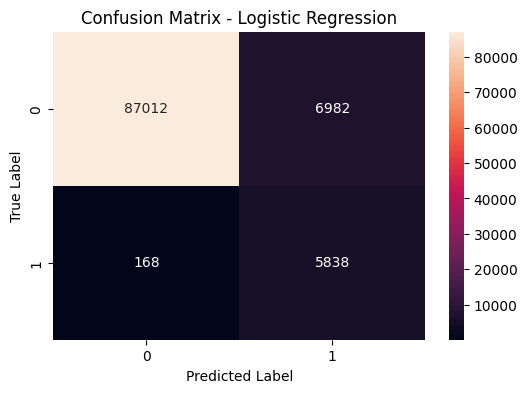

array([[87012,  6982],
       [  168,  5838]])

In [19]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

cm_lr

#### 9.Random Forest
进一步使用随机森林模型进行对比，观察非线性模型是否能够提升故障识别效果。

In [20]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.92306
Precision: 0.4372210651591788
Recall: 0.9786879786879786
F1-score: 0.6044215938303342
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     93994
           1       0.44      0.98      0.60      6006

    accuracy                           0.92    100000
   macro avg       0.72      0.95      0.78    100000
weighted avg       0.96      0.92      0.94    100000



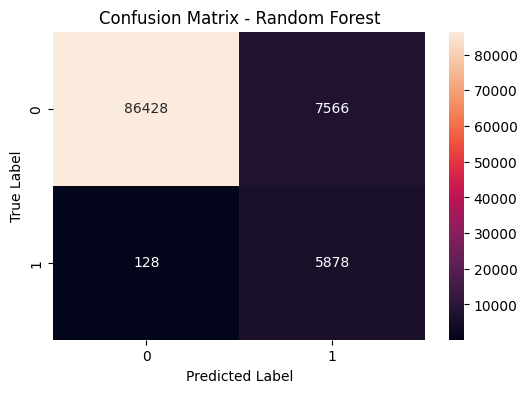

array([[86428,  7566],
       [  128,  5878]])

In [21]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Random Forest')
plt.show()

cm_rf

#### Model Comparison

In [22]:
model_compare = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

model_compare

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.92850,0.455382,0.972028,0.620206
1,Random Forest,0.92306,0.437221,0.978688,0.604422


<Figure size 800x500 with 0 Axes>

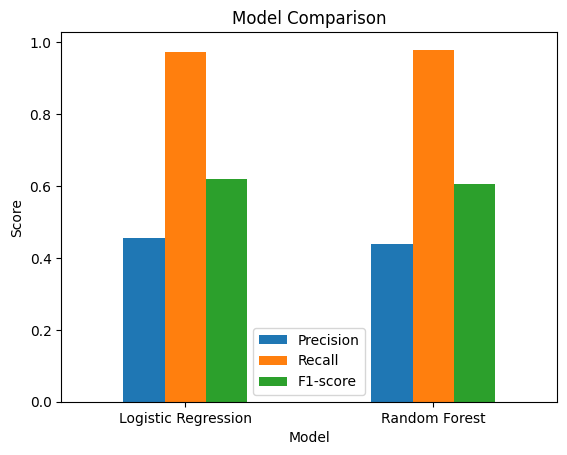

In [23]:
plt.figure(figsize=(8, 5))
model_compare.set_index('Model')[['Precision', 'Recall', 'F1-score']].plot(kind='bar')
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

#### 11.Threshold Optimization
逻辑回归默认以 0.5 作为分类阈值。由于初始模型 Recall 较高但 Precision 偏低，说明误报较多，因此进一步调整预测阈值，在 Precision 和 Recall 之间进行权衡。

In [24]:
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

threshold_results = []

for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_threshold = (y_prob_lr >= threshold).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, y_pred_threshold),
        'Precision': precision_score(y_test, y_pred_threshold),
        'Recall': recall_score(y_test, y_pred_threshold),
        'F1-score': f1_score(y_test, y_pred_threshold)
    })

threshold_compare = pd.DataFrame(threshold_results)
threshold_compare

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.5,0.92850,0.455382,0.972028,0.620206
1,0.6,0.93683,0.486839,0.957709,0.645531
2,0.7,0.94522,0.524733,0.932567,0.671583
3,0.8,0.95394,0.575366,0.889777,0.698836
4,0.9,0.96226,0.652793,0.793873,0.716454


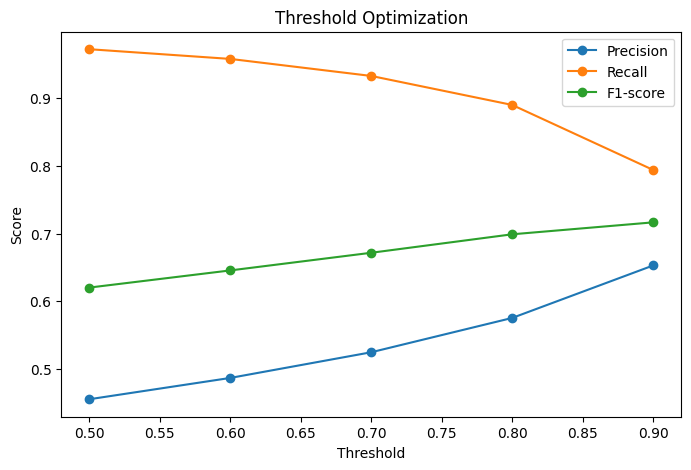

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(threshold_compare['Threshold'], threshold_compare['Precision'], marker='o', label='Precision')
plt.plot(threshold_compare['Threshold'], threshold_compare['Recall'], marker='o', label='Recall')
plt.plot(threshold_compare['Threshold'], threshold_compare['F1-score'], marker='o', label='F1-score')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Optimization')
plt.legend()
plt.show()

In [26]:
best_threshold = 0.9
y_pred_09 = (y_prob_lr >= best_threshold).astype(int)

print("Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, y_pred_09))
print("Precision:", precision_score(y_test, y_pred_09))
print("Recall:", recall_score(y_test, y_pred_09))
print("F1-score:", f1_score(y_test, y_pred_09))

print(classification_report(y_test, y_pred_09))

Threshold: 0.9
Accuracy: 0.96226
Precision: 0.6527929901423878
Recall: 0.7938727938727939
F1-score: 0.7164537941397445
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     93994
           1       0.65      0.79      0.72      6006

    accuracy                           0.96    100000
   macro avg       0.82      0.88      0.85    100000
weighted avg       0.97      0.96      0.96    100000



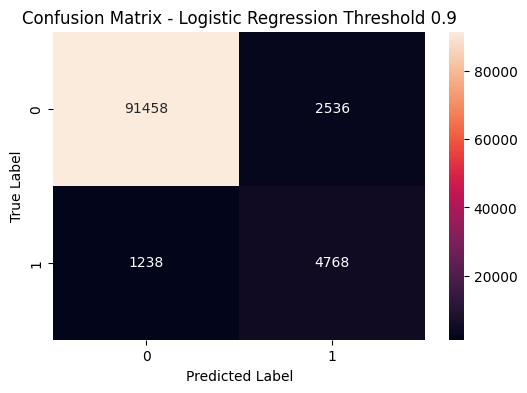

array([[91458,  2536],
       [ 1238,  4768]])

In [27]:
cm_09 = confusion_matrix(y_test, y_pred_09)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_09, annot=True, fmt='d')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression Threshold 0.9')
plt.show()

cm_09

#### 12.Feature Importance
使用随机森林的特征重要性进一步观察模型主要依赖哪些变量进行故障预测。

In [28]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

importance

,Feature,Importance
1,Operational_Hours,0.961689
3,Vibration_mms,0.008326
2,Temperature_C,0.006473
7,Power_Consumption_kW,0.003076
4,Sound_dB,0.002903
5,Oil_Level_pct,0.002741
8,Last_Maintenance_Days_Ago,0.002678
6,Coolant_Level_pct,0.002469
0,Installation_Year,0.001833
9,Maintenance_History_Count,0.001402


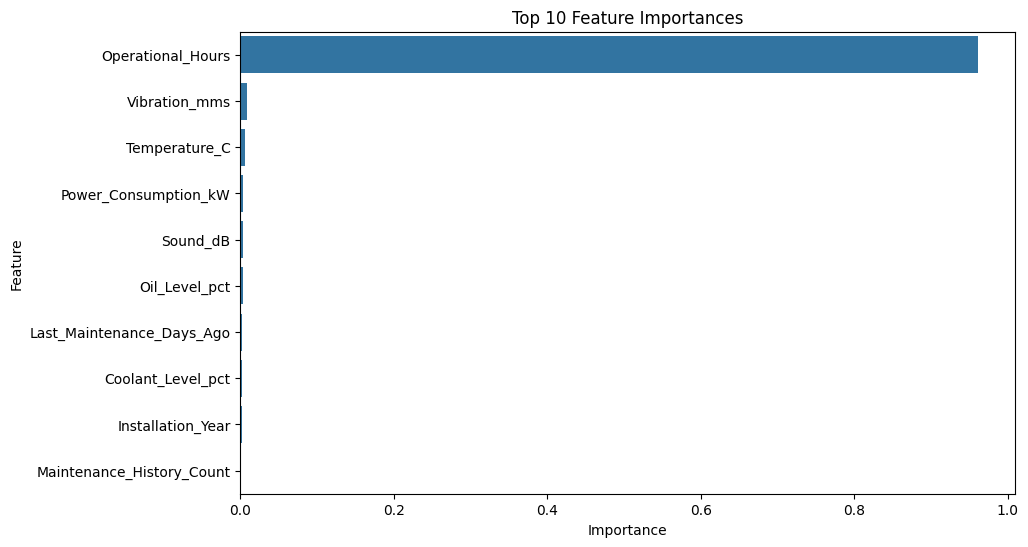

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importances')
plt.show()

### Conclusion

本项目基于 Kaggle 工厂传感器模拟数据完成了设备 7 天内故障预测任务。

主要结论如下：

1. 数据存在明显类别不平衡，故障样本约占 6%，因此模型评估不能只关注 Accuracy，而应重点关注 Precision、Recall 和 F1-score。
2. 统计分析显示，`Operational_Hours` 是与故障风险关系最强的变量，故障组平均运行时长明显高于非故障组。
3. 初始逻辑回归模型具有较高 Recall，能够识别大部分故障设备，但 Precision 偏低，存在一定误报。
4. 与随机森林相比，逻辑回归在当前特征集下 F1-score 更高，整体表现更均衡。
5. 通过阈值优化，将逻辑回归分类阈值从 0.5 提高到 0.9 后，Precision 和 F1-score 得到明显提升，模型误报问题得到缓解。
6. 建模过程中删除了由目标变量直接转化得到的 `Failure_Label`，避免数据泄露，保证模型评估结果更加可靠。

该项目完整覆盖了数据清洗、EDA、统计检验、特征工程、模型训练、模型评估和阈值优化流程。